# **Análisis de calidad de vida urbana y conectividad en ciudades españolas**

El objetivo de este análisis es estudiar cómo influyen factores de conectividad, transporte, clima y precio de vivienda en la calidad de vida de municipios españoles.

Se analizan 999 municipios utilizando variables relacionadas con:

- Movilidad y conectividad
- Mercado inmobiliario
- Calidad del aire
- Condiciones climáticas

El propósito es identificar patrones, relaciones y oportunidades estratégicas.

# Análisis en Python

Carga de librerías y dataset

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12,7)

# Cargar dataset
df = pd.read_csv('drive/MyDrive/datos_agregados_ciudades.csv', sep=';')

df.head()

,Municipio,Provincia,Comunidad Autónoma,Habitantes (2022),Carril Bici,Precios alquiler,Distancia a Madrid (km),Tiempo medio \nde viaje a Madrid \nen coche,Tiempo medio de viaje a Madrid en tren o autobús,Distancia a Barcelona (km),...,Patrimonio de la Humanidad,% días calidad del aire Buena,% días calidad del aire Razonablemente Buena,% días calidad del aire Regular,% días calidad del aire Desfavorable,% días calidad del aire Muy Desfavorable,% días calidad del aire Extremadamente Desfavorable,Ponderación calidad del aire,Horas de Sol medias\nanuales,Unnamed: 28
0,A Coruña,A Coruña,Galicia,244700.0,"20,4","9,1",593.0,5:37,4 h 32 min,1084.0,...,Sí,20,73,4,3,0,0,410,2.453,NaN
1,Albacete,Albacete,Castilla-La Mancha,172357.0,"24,4","7,1",260.0,2:34,1 h 37 min,545.0,...,NaN,3,72,16,9,0,0,369,3.282,NaN
2,Alcalá de Guadaíra,Sevilla,Andalucía,75917.0,N/D,"6,6",531.0,5:09,3 h 29 min,995.0,...,NaN,14,72,11,3,0,0,397,3.526,NaN
3,Alcalá de Henares,Madrid,Madrid,196888.0,28,"9,9",40.0,0:39,42 min,586.0,...,Sí,17,68,11,3,0,0,396,2.691,NaN
4,Alcobendas,Madrid,Madrid,117041.0,"53,8",12,24.0,0:25,22 min,613.0,...,NaN,22,67,8,3,0,0,408,2.691,NaN


**Limpieza y preparación de datos**

Se realizan los siguientes pasos:

- Eliminación de columnas innecesarias
- Conversión de valores "N/D" a NaN
- Conversión de formato decimal con coma a punto
- Conversión de columnas numéricas

In [199]:
# Eliminar columna innecesaria
df = df.drop(columns=["Unnamed: 28"], errors="ignore")

# Reemplazar valores no disponibles
df = df.replace("N/D", np.nan)

# Convertir columnas con coma decimal
cols_to_clean = [
    "Carril Bici",
    "Precios alquiler"
]

for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(",", ".")
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 28 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Municipio                                                      101 non-null    object 
 1   Provincia                                                      101 non-null    object 
 2   Comunidad Autónoma                                             101 non-null    object 
 3   Habitantes (2022)                                              101 non-null    float64
 4   Carril Bici                                                    77 non-null     float64
 5   Precios alquiler                                               100 non-null    float64
 6   Distancia a Madrid (km)                                        101 non-null    float64
 7   Tiempo medio 
de viaje a Madrid 
en coche                     

# Preguntas de Análisis

**¿Qué municipios presentan mejor equilibrio entre aire, sol y precio de vivienda?**

Para aproximar la calidad de vida urbana se crea un índice simple combinando:

- Calidad del aire
- Horas de sol
- Precio medio de vivienda

Se asigna mayor peso a la calidad del aire por su impacto directo en bienestar.

In [210]:
# Reemplazar N/D por NaN
df = df.replace("N/D", np.nan)

# Función para convertir columnas con coma decimal a float
def limpiar_columna_numerica(col):
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace("€", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Columnas clave para el análisis
columnas_numericas = [
    "Ponderación calidad del aire",
    "Horas de Sol medias\nanuales",
    "Precio medio vivienda (EUR/m2)",
    "Número de\nconexiones del\naeropuerto internacional\nmás cercano",
    "Distancia a Madrid (km)",
    "Distancia a Barcelona (km)"
]

for col in columnas_numericas:
    if col in df.columns:
        limpiar_columna_numerica(col)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 31 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Municipio                                                      101 non-null    object 
 1   Provincia                                                      101 non-null    object 
 2   Comunidad Autónoma                                             101 non-null    object 
 3   Habitantes (2022)                                              101 non-null    float64
 4   Carril Bici                                                    77 non-null     float64
 5   Precios alquiler                                               100 non-null    float64
 6   Distancia a Madrid (km)                                        101 non-null    float64
 7   Tiempo medio 
de viaje a Madrid 
en coche                     

In [203]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

variables_indice = [
    "Ponderación calidad del aire",
    "Horas de Sol medias\nanuales",
    "Precio medio vivienda (EUR/m2)"
]

df_norm = df[variables_indice].dropna()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_norm),
    columns=variables_indice,
    index=df_norm.index
)

# Crear índice
df.loc[df_scaled.index, "Indice_Calidad_Vida"] = (
    df_scaled["Ponderación calidad del aire"] * 0.4 +
    df_scaled["Horas de Sol medias\nanuales"] * 0.3 -
    df_scaled["Precio medio vivienda (EUR/m2)"] * 0.3
)

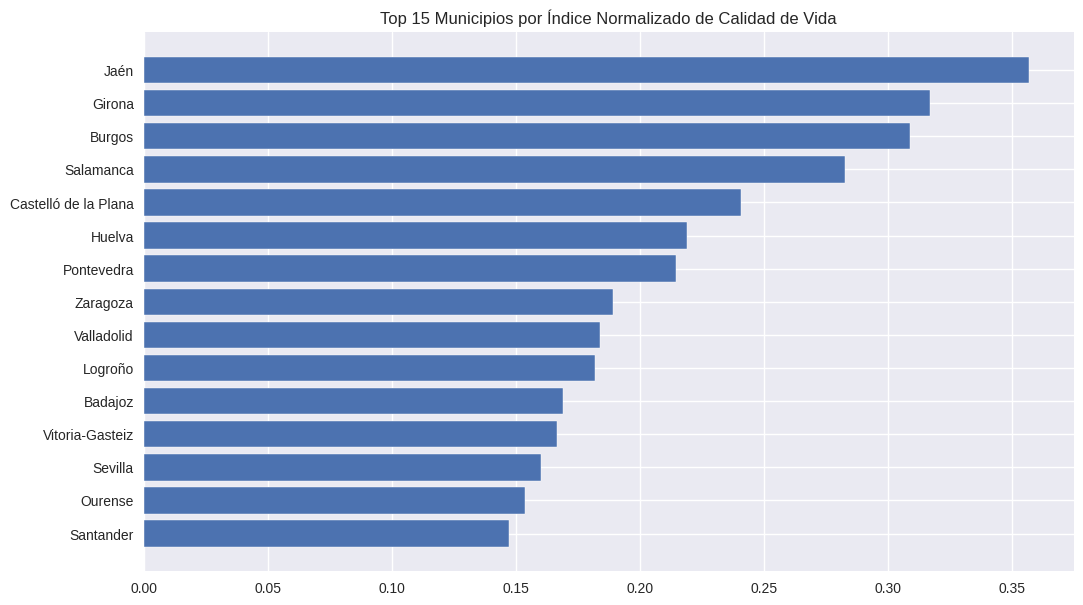

In [204]:
top = df.sort_values("Indice_Calidad_Vida", ascending=False).head(15)

plt.barh(top["Municipio"], top["Indice_Calidad_Vida"])
plt.gca().invert_yaxis()
plt.title("Top 15 Municipios por Índice Normalizado de Calidad de Vida")
plt.show()

Las ciudades con mejor puntuación ambiental tienden a situarse fuera de grandes núcleos industriales.

**¿Influye la conectividad en el precio de la vivienda?**

Se analiza si el número de conexiones del aeropuerto internacional más cercano guarda relación con el precio medio de vivienda.\





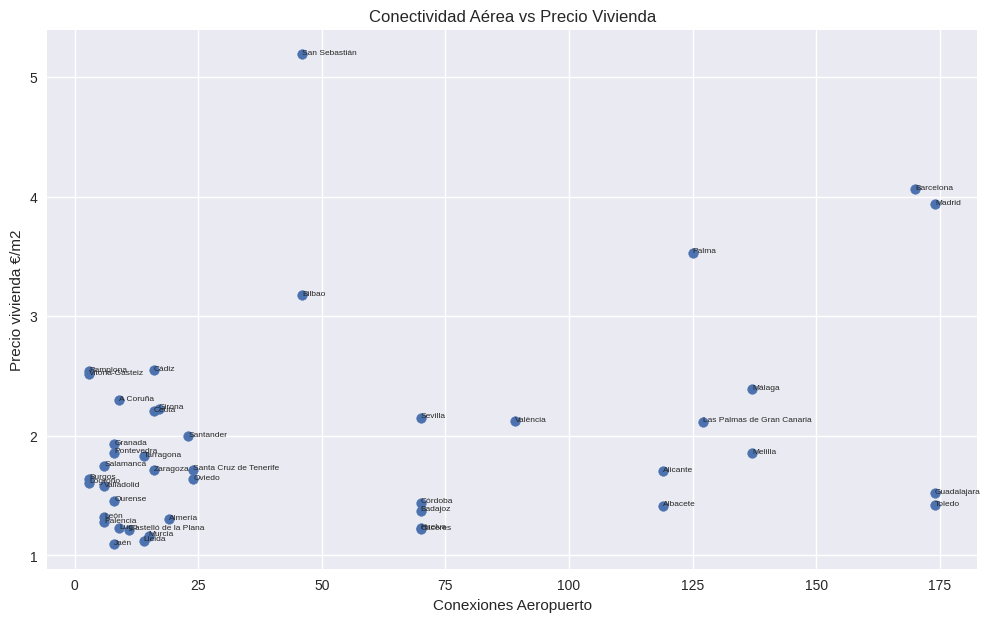

,Número de\nconexiones del\naeropuerto internacional\nmás cercano,Precio medio vivienda (EUR/m2)
Número de\nconexiones del\naeropuerto internacional\nmás cercano,1.00000,0.31003
Precio medio vivienda (EUR/m2),0.31003,1.00000


In [206]:
x = "Número de\nconexiones del\naeropuerto internacional\nmás cercano"
y = "Precio medio vivienda (EUR/m2)"

plt.scatter(df[x], df[y])

for i in range(len(df)):
    plt.text(df[x].iloc[i], df[y].iloc[i], df["Municipio"].iloc[i], fontsize=6)

plt.xlabel("Conexiones Aeropuerto")
plt.ylabel("Precio vivienda €/m2")
plt.title("Conectividad Aérea vs Precio Vivienda")
plt.show()

df[[x, y]].corr()

Se observa una correlación positiva moderada entre número de conexiones aéreas y precio medio de vivienda.

**¿La proximidad a Madrid o Barcelona encarece los municipios?**

Se calcula la distancia mínima a Madrid o Barcelona y se compara con el precio de vivienda.

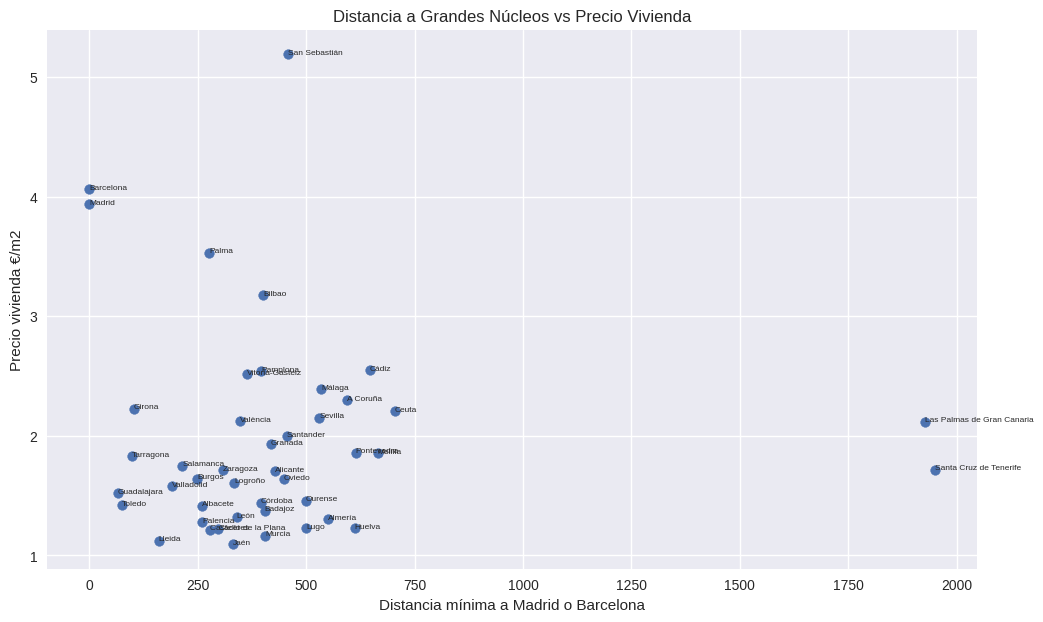

In [207]:
df["Distancia_Minima"] = df[
    ["Distancia a Madrid (km)", "Distancia a Barcelona (km)"]
].min(axis=1)

plt.scatter(df["Distancia_Minima"],
            df["Precio medio vivienda (EUR/m2)"])

for i in range(len(df)):
    plt.text(df["Distancia_Minima"].iloc[i],
             df["Precio medio vivienda (EUR/m2)"].iloc[i],
             df["Municipio"].iloc[i],
             fontsize=6)

plt.xlabel("Distancia mínima a Madrid o Barcelona")
plt.ylabel("Precio vivienda €/m2")
plt.title("Distancia a Grandes Núcleos vs Precio Vivienda")
plt.show()

Los municipios más próximos a grandes centros urbanos presentan precios significativamente superiores,

**¿Existen municipios infravalorados?**

Se construye un ratio simple que relaciona calidad ambiental y clima frente a precio de vivienda.


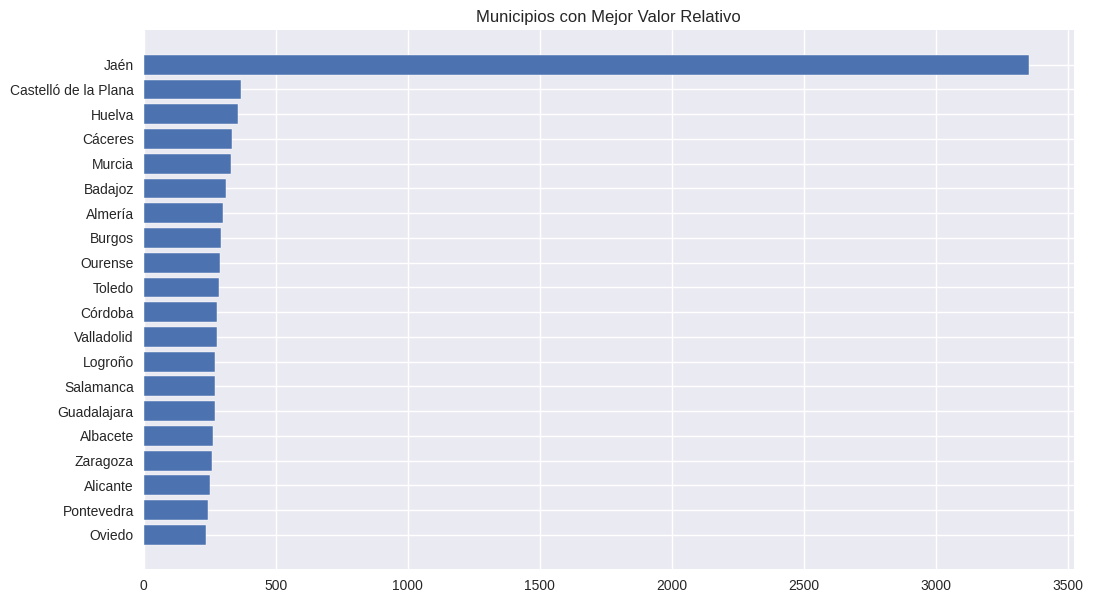

In [208]:
df["Valor_Relativo"] = (
    df["Ponderación calidad del aire"] +
    df["Horas de Sol medias\nanuales"]
) / df["Precio medio vivienda (EUR/m2)"]

top_valor = df.sort_values("Valor_Relativo", ascending=False).head(20)

plt.barh(top_valor["Municipio"], top_valor["Valor_Relativo"])
plt.gca().invert_yaxis()
plt.title("Municipios con Mejor Valor Relativo")
plt.show()

Se identifican municipios con buena calidad ambiental y precios relativamente bajos, lo que podría representar oportunidades de desarrollo o inversión futura.

**Matriz de correlación**

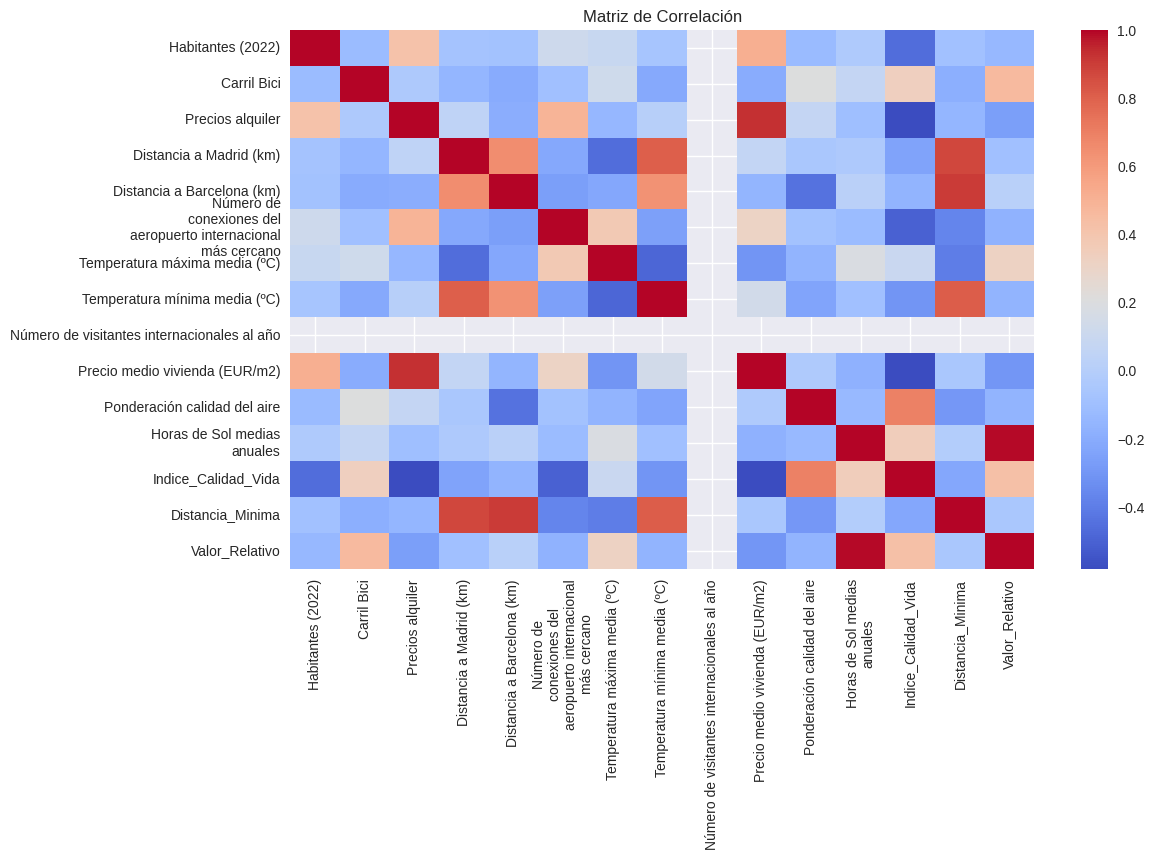

In [209]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

La matriz de correlación muestra que el precio de vivienda está más relacionado con la proximidad urbana que con variables climáticas.

### Conclusiones Principales

1. La conectividad aérea influye en el precio, pero no lo explica completamente.

2. La proximidad a Madrid o Barcelona es uno de los principales determinantes del coste inmobiliario.

3. Existen municipios con alto valor relativo que combinan buena calidad ambiental y precios accesibles.

4. La calidad de vida urbana no depende exclusivamente de infraestructura, sino del equilibrio entre factores.



Borja

Analista de datos junior